In [3]:
from google.colab import files

uploaded = files.upload()

Saving student_performance_clean.csv to student_performance_clean.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [5]:
df = pd.read_csv('student_performance_clean.csv')

print("Ukuran dataset:", df.shape)
display(df.head())

Ukuran dataset: (12467, 16)


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


In [6]:
print("Nama kolom:")
print(df.columns.tolist())

print("\nInformasi dataset:")
df.info()

Nama kolom:
['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore', 'EduTech', 'StressLevel', 'FinalGrade']

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12467 entries, 0 to 12466
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            12467 non-null  int64
 1   Attendance            12467 non-null  int64
 2   Resources             12467 non-null  int64
 3   Extracurricular       12467 non-null  int64
 4   Motivation            12467 non-null  int64
 5   Internet              12467 non-null  int64
 6   Gender                12467 non-null  int64
 7   Age                   12467 non-null  int64
 8   LearningStyle         12467 non-null  int64
 9   OnlineCourses         12467 non-null  int64
 10  Discussions           12467 non-null

In [7]:
df['Perlu_Pendampingan'] = (
    (df['Attendance'] < 70) |
    (df['AssignmentCompletion'] < 60) |
    (df['ExamScore'] < 60) |
    (df['StudyHours'] < 10)
).map({
    True: 'Ya',
    False: 'Tidak'
})

print("Distribusi target:")

print(df['Perlu_Pendampingan'].value_counts())

print("\nPersentase target:")

print(
    df['Perlu_Pendampingan']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Distribusi target:
Perlu_Pendampingan
Ya       7540
Tidak    4927
Name: count, dtype: int64

Persentase target:
Perlu_Pendampingan
Ya       60.48
Tidak    39.52
Name: proportion, dtype: float64


In [8]:
X = df[
    [
        'StudyHours',
        'Attendance',
        'AssignmentCompletion',
        'OnlineCourses',
        'Discussions',
        'ExamScore',
        'FinalGrade'
    ]
]

y = df['Perlu_Pendampingan']

print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)

Ukuran X: (12467, 7)
Ukuran y: (12467,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)

Data training: (9973, 7)
Data testing : (2494, 7)


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Standardisasi untuk KNN selesai.")

Standardisasi untuk KNN selesai.


In [11]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree berhasil dibuat.")

Decision Tree berhasil dibuat.


In [12]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest berhasil dibuat.")

Random Forest berhasil dibuat.


In [13]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN berhasil dibuat.")

KNN berhasil dibuat.


In [14]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes berhasil dibuat.")

Naive Bayes berhasil dibuat.


In [36]:
print("Label sebenarnya:")
print(y_test.unique())

print("\nPrediksi Decision Tree:")
print(np.unique(y_pred_dt))

print("\nPrediksi Random Forest:")
print(np.unique(y_pred_rf))

print("\nPrediksi KNN:")
print(np.unique(y_pred_knn))

print("\nPrediksi Naive Bayes:")
print(np.unique(y_pred_nb))

Label sebenarnya:
['Tidak' 'Ya']

Prediksi Decision Tree:
['Tidak' 'Ya']

Prediksi Random Forest:
['Tidak' 'Ya']

Prediksi KNN:
['Tidak' 'Ya']

Prediksi Naive Bayes:
['Tidak' 'Ya']


In [35]:
# ==========================================
# TESTING 4 MODEL
# ==========================================

print("==========================================")
print("          TESTING MODEL KLASIFIKASI")
print("==========================================")

# Prediksi menggunakan data testing

y_pred_dt = dt_model.predict(X_test)

y_pred_rf = rf_model.predict(X_test)

y_pred_knn = knn_model.predict(X_test_scaled)

y_pred_nb = nb_model.predict(X_test)


print("\nTesting selesai.")
print("Jumlah data testing :", len(y_test))

          TESTING MODEL KLASIFIKASI

Testing selesai.
Jumlah data testing : 2494


In [ ]:
# ==========================================
# HASIL TESTING
# ==========================================

print("=== HASIL TESTING ===\n")

print("Decision Tree")
print(classification_report(
    y_test,
    y_pred_dt,
    zero_division=0
))

print("\nRandom Forest")
print(classification_report(
    y_test,
    y_pred_rf,
    zero_division=0
))

print("\nKNN")
print(classification_report(
    y_test,
    y_pred_knn,
    zero_division=0
))

print("\nNaive Bayes")
print(classification_report(
    y_test,
    y_pred_nb,
    zero_division=0
))

In [16]:
# ==========================================
# 14. EVALUASI 4 ALGORITMA
# ==========================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Pastikan semua label berbentuk string
y_test_eval = y_test.astype(str)

y_pred_dt_eval = pd.Series(y_pred_dt).astype(str)
y_pred_rf_eval = pd.Series(y_pred_rf).astype(str)
y_pred_knn_eval = pd.Series(y_pred_knn).astype(str)
y_pred_nb_eval = pd.Series(y_pred_nb).astype(str)


def evaluasi_model(nama_model, y_asli, y_prediksi):

    return {
        'Algoritma': nama_model,

        'Accuracy': accuracy_score(
            y_asli,
            y_prediksi
        ),

        'Precision': precision_score(
            y_asli,
            y_prediksi,
            labels=['Ya', 'Tidak'],
            pos_label='Ya',
            zero_division=0
        ),

        'Recall': recall_score(
            y_asli,
            y_prediksi,
            labels=['Ya', 'Tidak'],
            pos_label='Ya',
            zero_division=0
        ),

        'F1-Score': f1_score(
            y_asli,
            y_prediksi,
            labels=['Ya', 'Tidak'],
            pos_label='Ya',
            zero_division=0
        )
    }


hasil = pd.DataFrame([

    evaluasi_model(
        'Decision Tree',
        y_test_eval,
        y_pred_dt_eval
    ),

    evaluasi_model(
        'Random Forest',
        y_test_eval,
        y_pred_rf_eval
    ),

    evaluasi_model(
        'KNN',
        y_test_eval,
        y_pred_knn_eval
    ),

    evaluasi_model(
        'Naive Bayes',
        y_test_eval,
        y_pred_nb_eval
    )

])


# Membulatkan angka
kolom_metrik = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score'
]

hasil[kolom_metrik] = hasil[kolom_metrik].round(4)


print("=== HASIL EVALUASI 4 ALGORITMA ===")

display(hasil)

=== HASIL EVALUASI 4 ALGORITMA ===


,Algoritma,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,1.0000,1.0000,1.0000,1.0000
1,Random Forest,1.0000,1.0000,1.0000,1.0000
2,KNN,0.9495,0.9631,0.9529,0.9580
3,Naive Bayes,0.8039,0.8431,0.8302,0.8366


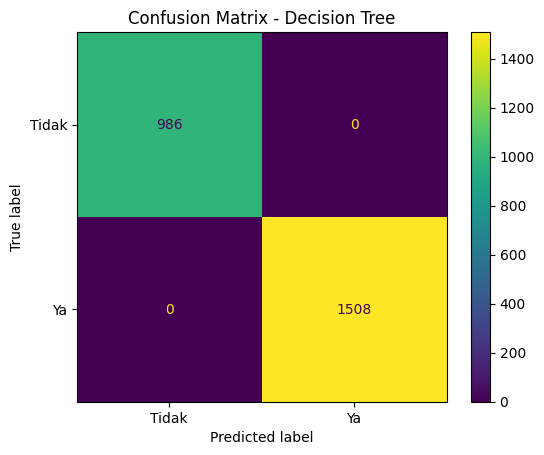

In [17]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt,
    labels=['Tidak', 'Ya']
)

disp_dt = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=['Tidak', 'Ya']
)

disp_dt.plot()

plt.title('Confusion Matrix - Decision Tree')

plt.show()

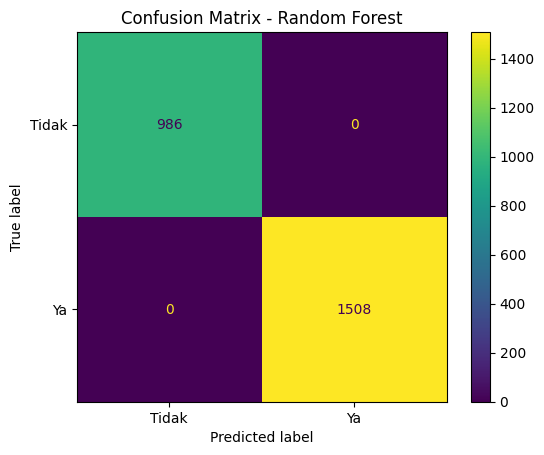

In [18]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=['Tidak', 'Ya']
)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Tidak', 'Ya']
)

disp_rf.plot()

plt.title('Confusion Matrix - Random Forest')

plt.show()

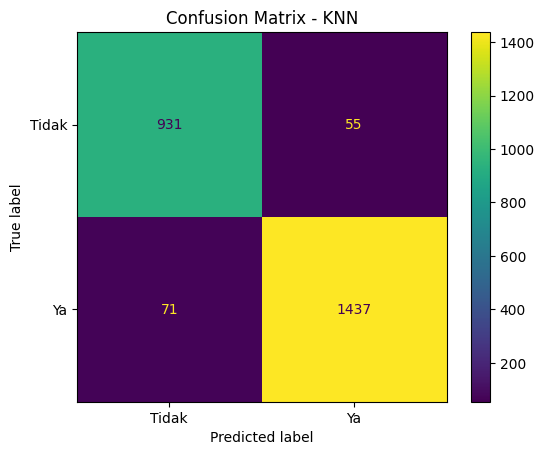

In [19]:
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn,
    labels=['Tidak', 'Ya']
)

disp_knn = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=['Tidak', 'Ya']
)

disp_knn.plot()

plt.title('Confusion Matrix - KNN')

plt.show()

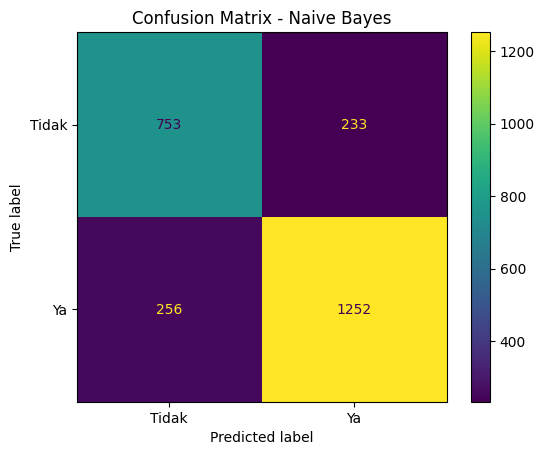

In [20]:
cm_nb = confusion_matrix(
    y_test,
    y_pred_nb,
    labels=['Tidak', 'Ya']
)

disp_nb = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=['Tidak', 'Ya']
)

disp_nb.plot()

plt.title('Confusion Matrix - Naive Bayes')

plt.show()

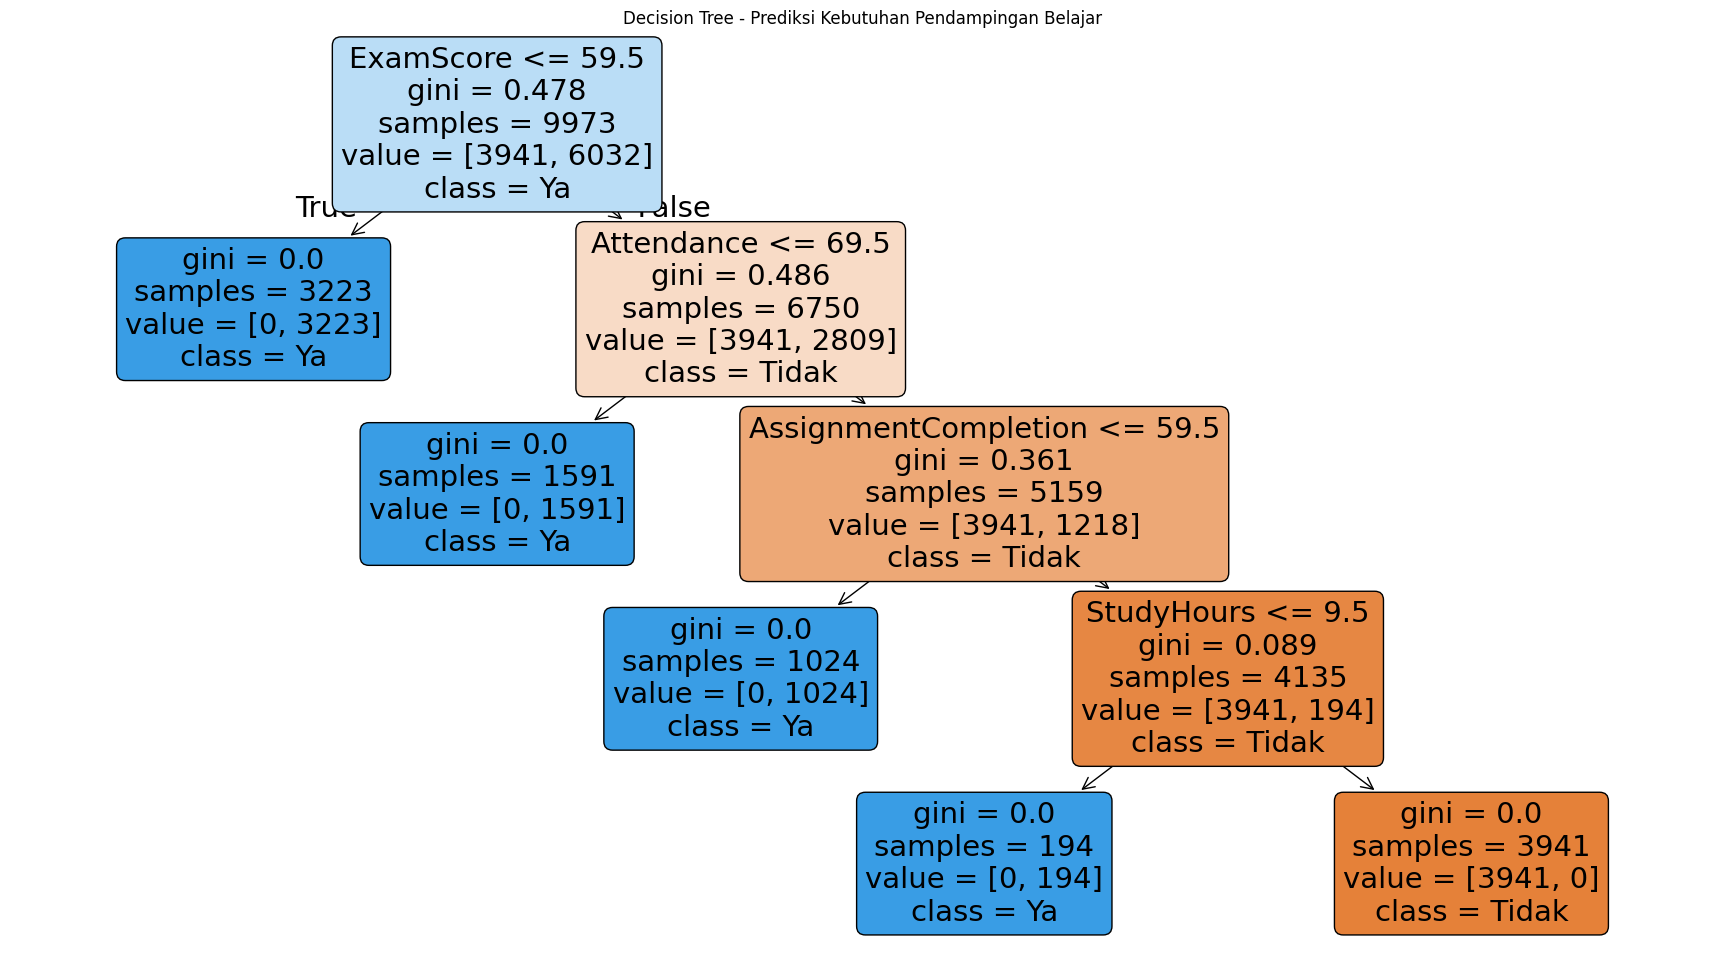

In [21]:
plt.figure(figsize=(22, 12))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['Tidak', 'Ya'],
    filled=True,
    rounded=True
)

plt.title(
    'Decision Tree - Prediksi Kebutuhan Pendampingan Belajar'
)

plt.show()

In [22]:
importance_dt = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': dt_model.feature_importances_
})

importance_dt = importance_dt.sort_values(
    by='Importance',
    ascending=False
)

display(importance_dt)

,Fitur,Importance
2,AssignmentCompletion,0.312773
5,ExamScore,0.311962
1,Attendance,0.297695
0,StudyHours,0.077569
3,OnlineCourses,0.000000
4,Discussions,0.000000
6,FinalGrade,0.000000


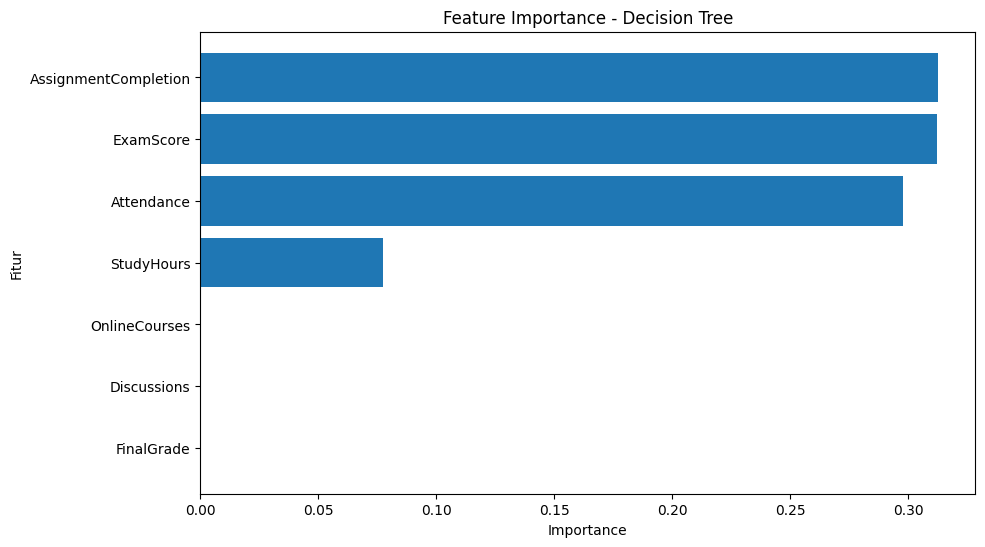

In [23]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance_dt['Fitur'],
    importance_dt['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Fitur')

plt.title(
    'Feature Importance - Decision Tree'
)

plt.gca().invert_yaxis()

plt.show()

In [24]:
importance_rf = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': rf_model.feature_importances_
})

importance_rf = importance_rf.sort_values(
    by='Importance',
    ascending=False
)

display(importance_rf)

,Fitur,Importance
1,Attendance,0.302563
5,ExamScore,0.278499
2,AssignmentCompletion,0.248233
6,FinalGrade,0.105039
0,StudyHours,0.057915
3,OnlineCourses,0.006531
4,Discussions,0.001220


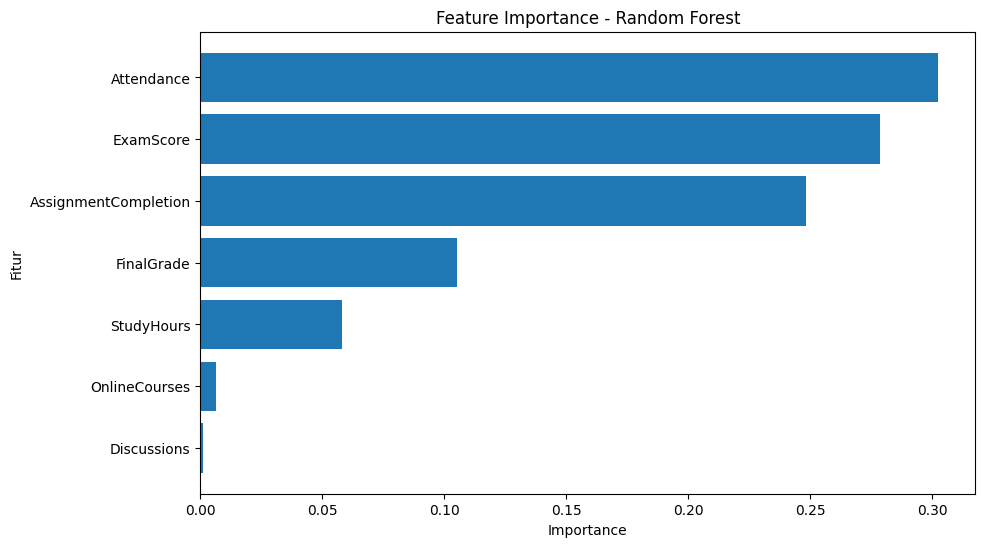

In [25]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance_rf['Fitur'],
    importance_rf['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Fitur')

plt.title(
    'Feature Importance - Random Forest'
)

plt.gca().invert_yaxis()

plt.show()

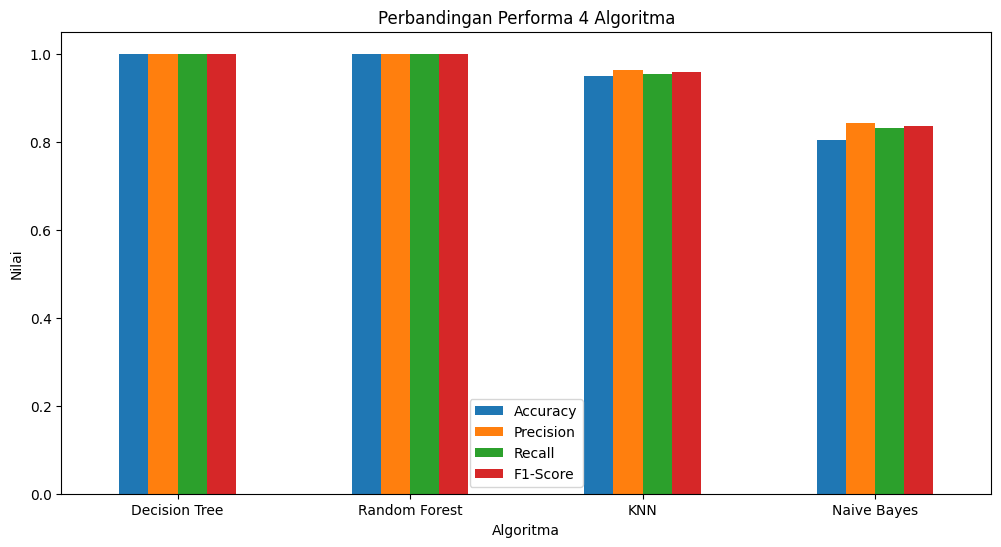

In [26]:
hasil_plot = hasil.set_index('Algoritma')

hasil_plot[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score']
].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Perbandingan Performa 4 Algoritma')

plt.xlabel('Algoritma')

plt.ylabel('Nilai')

plt.ylim(0, 1.05)

plt.xticks(rotation=0)

plt.legend()

plt.show()

In [51]:
mahasiswa_baru = pd.DataFrame([{
    'StudyHours':100,
    'Attendance': 100,
    'AssignmentCompletion':100,
    'OnlineCourses': 100,
    'Discussions': 100,
    'ExamScore': 100,
    'FinalGrade': 100
}])

In [52]:
mahasiswa_baru_scaled = scaler.transform(
    mahasiswa_baru
)

In [53]:
prediksi_dt = dt_model.predict(
    mahasiswa_baru
)

prediksi_rf = rf_model.predict(
    mahasiswa_baru
)

prediksi_knn = knn_model.predict(
    mahasiswa_baru_scaled
)

prediksi_nb = nb_model.predict(
    mahasiswa_baru
)

print("=== HASIL PREDIKSI ===")

print("Decision Tree :", prediksi_dt[0])

print("Random Forest :", prediksi_rf[0])

print("KNN           :", prediksi_knn[0])

print("Naive Bayes   :", prediksi_nb[0])

=== HASIL PREDIKSI ===
Decision Tree : Tidak
Random Forest : Ya
KNN           : Ya
Naive Bayes   : Ya


In [54]:
hasil_prediksi = pd.DataFrame({
    'Algoritma': [
        'Decision Tree',
        'Random Forest',
        'KNN',
        'Naive Bayes'
    ],

    'Prediksi': [
        prediksi_dt[0],
        prediksi_rf[0],
        prediksi_knn[0],
        prediksi_nb[0]
    ]
})

display(hasil_prediksi)

,Algoritma,Prediksi
0,Decision Tree,Tidak
1,Random Forest,Ya
2,KNN,Ya
3,Naive Bayes,Ya


In [56]:
rekomendasi = []

if mahasiswa_baru.loc[0, 'Attendance'] <100:
    rekomendasi.append(
        'Pendampingan untuk meningkatkan kehadiran'
    )

if mahasiswa_baru.loc[0, 'AssignmentCompletion'] < 60:
    rekomendasi.append(
        'Pendampingan manajemen tugas'
    )

if mahasiswa_baru.loc[0, 'StudyHours'] < 10:
    rekomendasi.append(
        'Pendampingan manajemen waktu belajar'
    )

if mahasiswa_baru.loc[0, 'ExamScore'] < 60:
    rekomendasi.append(
        'Tutoring atau pendampingan akademik'
    )

if len(rekomendasi) == 0:
    rekomendasi.append(
        'Belum diperlukan pendampingan khusus'
    )

print("=== REKOMENDASI ===")

for nomor, r in enumerate(rekomendasi, 1):
    print(f"{nomor}. {r}")

=== REKOMENDASI ===
1. Belum diperlukan pendampingan khusus


In [57]:
joblib.dump(
    dt_model,
    'model_decision_tree_pendampingan.pkl'
)

joblib.dump(
    rf_model,
    'model_random_forest_pendampingan.pkl'
)

joblib.dump(
    knn_model,
    'model_knn_pendampingan.pkl'
)

joblib.dump(
    nb_model,
    'model_naive_bayes_pendampingan.pkl'
)

joblib.dump(
    scaler,
    'scaler_knn.pkl'
)

print("Semua model berhasil disimpan.")

Semua model berhasil disimpan.


In [58]:
df.to_csv(
    'dataset_pendampingan_mahasiswa.csv',
    index=False
)

print(
    "Dataset hasil berhasil disimpan."
)

Dataset hasil berhasil disimpan.


In [59]:
hasil.to_csv(
    'hasil_perbandingan_algoritma.csv',
    index=False
)

print(
    "Hasil evaluasi berhasil disimpan."
)

Hasil evaluasi berhasil disimpan.
